# Modelo de Machine Learning para estimación de precios de alojamiento en CulturaTrip

Este notebook presenta el desarrollo del modelo de regresión utilizado para estimar el coste del alojamiento dentro del prototipo analítico de CulturaTrip. El objetivo es predecir el precio esperado del hospedaje a partir de variables turísticas y contextuales, con el fin de incorporarlo al flujo de planificación inteligente del viaje.

## Objetivo del modelo

El objetivo de este modelo es estimar el precio del alojamiento turístico a partir de variables geográficas, temporales y de características del hospedaje. Esta predicción permite calcular de forma más realista el coste del alojamiento dentro del viaje y compararlo con el presupuesto disponible asignado a esta categoría.

En el contexto del proyecto CulturaTrip, el modelo no se utiliza como un ejercicio aislado de predicción, sino como un componente funcional dentro del simulador de presupuesto y del prototipo desarrollado en Streamlit.

In [103]:
import os
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_DIR = Path.cwd().resolve().parents[1]

OUTPUTS_DIR = BASE_DIR / "outputs" / "regresion_precios"
MODEL_DIR = OUTPUTS_DIR / "modelos"
ML_DIR = BASE_DIR / "data" / "Machine Learning"

input_largo = ML_DIR / "df_precios_largo.csv"
input_features = ML_DIR / "df_precios_features.csv"

metricas_path = ML_DIR / "metricas_modelos_regresion.csv"
metricas_rf_path = ML_DIR / "metricas_random_forest_optimizado.csv"

model_path = MODEL_DIR / "random_forest_precio.pkl"
features_path = MODEL_DIR / "features_modelo_precio.pkl"

print("ML_DIR:", ML_DIR)
print("MODEL_DIR:", MODEL_DIR)


ML_DIR: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning
MODEL_DIR: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos


## Preparación del dataset

La fase inicial consistió en transformar el dataset de alojamientos desde un formato ancho a un formato largo. Esta transformación fue necesaria para representar en una sola variable objetivo el precio del alojamiento, diferenciando explícitamente entre precios de noches entre semana y noches de fin de semana.

Cada registro resultante representa una observación de precio asociada a un tipo de día específico, lo que permite al modelo aprender patrones diferenciados según el comportamiento del mercado turístico.

In [104]:
input_path = BASE_DIR / "data" / "clean" / "df_alojamientos.csv"
output_path = ML_DIR / "df_precios_largo.csv"

df = pd.read_csv(input_path)

print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (10280, 15)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,tiene_valoraciones,fuente,granularidad_origen,es_dato_replicado,nivel_geografico,valoraciones_norm
0,1,ES,1,4,1,hotel 3 estrellas,1 mes,70.00,72.00,True,hotel_dataestur,provincia,False,provincia,3.7595
1,2,ES,1,4,1,hotel 3 estrellas,1 semana,71.00,73.67,True,hotel_dataestur,provincia,False,provincia,3.7595
2,3,ES,1,4,1,hotel 3 estrellas,2 semanas,71.00,73.67,True,hotel_dataestur,provincia,False,provincia,3.7595
3,4,ES,1,4,1,hotel 3 estrellas,3 meses,67.33,70.33,True,hotel_dataestur,provincia,False,provincia,3.7595
4,5,ES,1,4,1,hotel 4 estrellas,1 mes,75.33,78.67,True,hotel_dataestur,provincia,False,provincia,3.2400


In [106]:
df_largo = df.melt(
    id_vars=[
        "id_alojamiento",
        "id_pais",
        "id_ccaa",
        "id_provincia",
        "mes",
        "categoria_alojamiento",
        "periodo_antelacion",
        "tiene_valoraciones",
        "fuente",
        "granularidad_origen",
        "es_dato_replicado",
        "nivel_geografico",
        "valoraciones_norm"
    ],
    value_vars=[
        "precio_checkin_entre_semana",
        "precio_checkin_fin_semana"
    ],
    var_name="tipo_dia_original",
    value_name="precio"
)

map_tipo_dia = {
    "precio_checkin_entre_semana": "semana",
    "precio_checkin_fin_semana": "fin_semana"
}

df_largo["tipo_dia"] = df_largo["tipo_dia_original"].map(map_tipo_dia)

columnas_finales = [
    "id_alojamiento",
    "id_pais",
    "id_ccaa",
    "id_provincia",
    "mes",
    "categoria_alojamiento",
    "periodo_antelacion",
    "valoraciones_norm",
    "tiene_valoraciones",
    "tipo_dia",
    "precio"
]

df_largo = df_largo[columnas_finales].copy()
df_largo.to_csv(output_path, index=False, encoding="utf-8")

print("Dimensiones formato largo:", df_largo.shape)
display(df_largo.head())
display(df_largo["tipo_dia"].value_counts())

Dimensiones formato largo: (20560, 11)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,categoria_alojamiento,periodo_antelacion,valoraciones_norm,tiene_valoraciones,tipo_dia,precio
0,1,ES,1,4,1,hotel 3 estrellas,1 mes,3.7595,True,semana,70.00
1,2,ES,1,4,1,hotel 3 estrellas,1 semana,3.7595,True,semana,71.00
2,3,ES,1,4,1,hotel 3 estrellas,2 semanas,3.7595,True,semana,71.00
3,4,ES,1,4,1,hotel 3 estrellas,3 meses,3.7595,True,semana,67.33
4,5,ES,1,4,1,hotel 4 estrellas,1 mes,3.2400,True,semana,75.33


tipo_dia
semana        10280
fin_semana    10280
Name: count, dtype: int64

## Feature engineering

Posteriormente se realizó una etapa de ingeniería de variables con el fin de preparar una base adecuada para el entrenamiento del modelo. En esta fase se construyeron y codificaron variables relevantes para la predicción del precio del alojamiento, entre ellas:

- mes del viaje
- temporada
- categoría del alojamiento
- periodo de antelación de la reserva
- presencia de valoraciones
- nivel de valoraciones
- tipo de día

Estas transformaciones permitieron convertir variables categóricas en variables numéricas interpretables por los algoritmos de regresión y, al mismo tiempo, reflejar mejor la dinámica del precio turístico.

In [107]:
output_features_path = ML_DIR / "df_precios_features.csv"

df = df_largo.copy()

def clasificar_temporada(mes):
    if mes in [12, 1, 2]:
        return "baja"
    elif mes in [3, 4, 5, 10, 11]:
        return "media"
    elif mes in [6, 7, 8, 9]:
        return "alta"
    else:
        return "desconocida"

df["temporada"] = df["mes"].apply(clasificar_temporada)

map_tipo_dia = {"semana": 0, "fin_semana": 1}
df["tipo_dia_cod"] = df["tipo_dia"].map(map_tipo_dia)

map_categoria = {
    "hotel 3 estrellas": 1,
    "hotel 4 estrellas": 2,
    "hotel 5 estrellas": 3,
    "apartamento": 4,
    "casa entera": 5,
    "habitacion privada": 6,
    "habitacion compartida": 7,
    "alternativo": 8
}
df["categoria_alojamiento_cod"] = df["categoria_alojamiento"].map(map_categoria)

map_antelacion = {
    "1 semana": 1,
    "2 semanas": 2,
    "1 mes": 3,
    "2-3 meses": 4,
    "3 meses": 5
}
df["periodo_antelacion_cod"] = df["periodo_antelacion"].map(map_antelacion)

map_temporada = {"baja": 1, "media": 2, "alta": 3}
df["temporada_cod"] = df["temporada"].map(map_temporada)

df["es_fin_de_semana"] = df["tipo_dia_cod"]

columnas_finales = [
    "id_alojamiento",
    "id_pais",
    "id_ccaa",
    "id_provincia",
    "mes",
    "temporada",
    "temporada_cod",
    "categoria_alojamiento",
    "categoria_alojamiento_cod",
    "periodo_antelacion",
    "periodo_antelacion_cod",
    "valoraciones_norm",
    "tiene_valoraciones",
    "tipo_dia",
    "tipo_dia_cod",
    "es_fin_de_semana",
    "precio"
]

df = df[columnas_finales].copy()
df.to_csv(output_features_path, index=False, encoding="utf-8")

print("Dimensiones dataset features:", df.shape)
display(df.head())
display(df.isnull().sum())

Dimensiones dataset features: (20560, 17)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,temporada,temporada_cod,categoria_alojamiento,categoria_alojamiento_cod,periodo_antelacion,periodo_antelacion_cod,valoraciones_norm,tiene_valoraciones,tipo_dia,tipo_dia_cod,es_fin_de_semana,precio
0,1,ES,1,4,1,baja,1,hotel 3 estrellas,1,1 mes,3,3.7595,True,semana,0,0,70.00
1,2,ES,1,4,1,baja,1,hotel 3 estrellas,1,1 semana,1,3.7595,True,semana,0,0,71.00
2,3,ES,1,4,1,baja,1,hotel 3 estrellas,1,2 semanas,2,3.7595,True,semana,0,0,71.00
3,4,ES,1,4,1,baja,1,hotel 3 estrellas,1,3 meses,5,3.7595,True,semana,0,0,67.33
4,5,ES,1,4,1,baja,1,hotel 4 estrellas,2,1 mes,3,3.2400,True,semana,0,0,75.33


id_alojamiento               0
id_pais                      0
id_ccaa                      0
id_provincia                 0
mes                          0
temporada                    0
temporada_cod                0
categoria_alojamiento        0
categoria_alojamiento_cod    0
periodo_antelacion           0
periodo_antelacion_cod       0
valoraciones_norm            0
tiene_valoraciones           0
tipo_dia                     0
tipo_dia_cod                 0
es_fin_de_semana             0
precio                       0
dtype: int64

## Variable objetivo y variables predictoras

La variable objetivo del modelo es el **precio** del alojamiento.

Las variables predictoras utilizadas fueron las siguientes:

- `id_ccaa`
- `id_provincia`
- `mes`
- `temporada_cod`
- `categoria_alojamiento_cod`
- `periodo_antelacion_cod`
- `valoraciones_norm`
- `tiene_valoraciones`
- `tipo_dia_cod`

La selección de estas variables responde a la hipótesis de que el precio del alojamiento depende de la localización geográfica, la temporalidad del viaje, el tipo de hospedaje, la anticipación de la reserva y la diferenciación entre noches de semana y fin de semana.

## Proceso de entrenamiento

Una vez definida la variable objetivo y las variables predictoras, el conjunto de datos se dividió en dos subconjuntos:

- 80% para entrenamiento
- 20% para prueba

Se utilizó una semilla aleatoria fija para asegurar la reproducibilidad de los resultados.

A continuación, se entrenaron los modelos base y se comparó su desempeño inicial sobre el conjunto de prueba. Esta estrategia permitió establecer una línea base y seleccionar el modelo con mejor comportamiento antes de pasar a la optimización de hiperparámetros.

In [108]:
features = [
    "id_ccaa",
    "id_provincia",
    "mes",
    "temporada_cod",
    "categoria_alojamiento_cod",
    "periodo_antelacion_cod",
    "valoraciones_norm",
    "tiene_valoraciones",
    "tipo_dia_cod"
]

X = df[features]
y = df["precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (16448, 9)
Tamaño prueba: (4112, 9)


## Comparación de modelos base

Antes de optimizar el modelo final, se realizó una comparación entre distintos algoritmos de regresión con el objetivo de identificar cuál ofrecía el mejor desempeño inicial sobre el problema planteado.

Se evaluaron tres modelos:
- Regresión lineal
- Random Forest Regressor
- Gradient Boosting Regressor

Esta comparación inicial permitió seleccionar el modelo más prometedor para la fase posterior de ajuste de hiperparámetros.

In [109]:
modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

resultados = []

for nombre_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "modelo": nombre_modelo,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)
df_resultados

,modelo,MAE,RMSE,R2
1,RandomForestRegressor,4.4545,11.9228,0.9823
2,GradientBoostingRegressor,25.7614,41.9583,0.7813
0,LinearRegression,58.7186,86.6425,0.0673


Para evaluar el desempeño de los modelos de regresión se utilizaron tres métricas principales: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) y R² (coeficiente de determinación). Estas métricas permiten medir la precisión de las predicciones del modelo respecto a los valores reales del precio del alojamiento.

El MAE representa el error absoluto promedio entre el valor real y el valor predicho. Esta métrica es fácilmente interpretable porque se expresa en las mismas unidades que la variable objetivo (precio). Un valor menor de MAE indica que el modelo comete errores de menor magnitud en promedio.

El RMSE mide la raíz del error cuadrático medio y penaliza con mayor intensidad los errores grandes. Por ello, esta métrica resulta útil para identificar si existen predicciones con desviaciones significativas respecto al valor real.

Por su parte, el coeficiente de determinación R² indica la proporción de la variabilidad del precio que puede ser explicada por las variables independientes incluidas en el modelo. Un valor cercano a 1 indica un mayor poder explicativo del modelo, mientras que valores más cercanos a 0 sugieren una capacidad limitada para explicar la variabilidad de los datos.

Tras comparar los diferentes algoritmos evaluados, el modelo Random Forest Regressor mostró el mejor desempeño global en términos de equilibrio entre error y capacidad explicativa. Este comportamiento es consistente con la naturaleza del problema, ya que los modelos basados en árboles suelen capturar mejor relaciones no lineales entre variables, así como interacciones complejas entre características del alojamiento, ubicación geográfica y factores temporales.

La selección de este modelo permite obtener estimaciones de precio más robustas, lo cual resulta especialmente relevante para el objetivo del proyecto CulturaTrip, donde se busca ofrecer estimaciones de presupuesto de viaje basadas en datos reales del mercado turístico.

En consecuencia, el modelo seleccionado se utilizará en la fase de simulación para estimar el coste del alojamiento en función de las características del viaje, permitiendo evaluar si el presupuesto del usuario es suficiente para el destino y periodo seleccionado.

## Selección del mejor modelo base

A partir de la comparación de métricas entre los modelos base, se seleccionó el algoritmo con mejor desempeño predictivo para proceder con su optimización. Esta decisión se tomó considerando principalmente el coeficiente de determinación \(R^2\), junto con los errores MAE y RMSE.

In [110]:
mejor_modelo_nombre = df_resultados.iloc[0]["modelo"]
print("Mejor modelo base seleccionado:", mejor_modelo_nombre)

Mejor modelo base seleccionado: RandomForestRegressor


In [111]:
metricas_path = ML_DIR / "metricas_modelos_regresion.csv"
df_resultados.to_csv(metricas_path, index=False, encoding="utf-8")
print(metricas_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\metricas_modelos_regresion.csv


El modelo Random Forest permite analizar la relevancia relativa de cada variable en la predicción del precio del alojamiento mediante la métrica de feature importance. Esta métrica indica cuánto contribuye cada variable a reducir el error de predicción dentro de los árboles del modelo.

Los resultados muestran que la variable más influyente es categoria_alojamiento_cod, con una importancia aproximada del 35.6 %. Esto indica que el tipo de alojamiento (por ejemplo, hotel de distintas categorías, apartamento o casa completa) es el factor que más explica las diferencias de precio entre observaciones. Este resultado es coherente con la lógica del mercado turístico, donde la categoría del alojamiento suele determinar gran parte del coste final.

En segundo lugar aparece id_ccaa (24.6 %), seguido por id_provincia (15.9 %), lo que evidencia que la localización geográfica también tiene un impacto significativo en el precio. Esto refleja las diferencias estructurales de precios entre regiones turísticas, donde ciertos destinos presentan niveles de coste superiores debido a factores como demanda turística, infraestructura o atractivo del destino.

Otra variable relevante es valoraciones_norm (14.9 %), lo que sugiere que las valoraciones o reputación del alojamiento influyen en el precio esperado. En plataformas turísticas es habitual que alojamientos mejor valorados puedan mantener precios más elevados.

En contraste, variables temporales como mes (4.4 %) y temporada_cod (2.6 %) presentan una influencia menor. Esto puede deberse a que el dataset ya refleja precios agregados o que las diferencias estacionales están parcialmente capturadas por otras variables del modelo.

Por último, variables como tipo_dia_cod (diferencia entre semana y fin de semana) y periodo_antelacion_cod muestran una contribución relativamente baja, mientras que tiene_valoraciones no presenta impacto significativo en el modelo, probablemente porque la información relevante ya está representada en la variable continua de valoraciones.

En conjunto, los resultados sugieren que las características estructurales del alojamiento y su ubicación geográfica son los principales determinantes del precio, mientras que los factores temporales y operativos tienen un papel secundario dentro del modelo.

Estos resultados son especialmente relevantes para la plataforma CulturaTrip, ya que permiten identificar los factores que más influyen en el coste del alojamiento y facilitan la estimación de presupuestos de viaje personalizados en función del destino y del tipo de hospedaje seleccionado por el usuario.

## Justificación del algoritmo elegido

Para el problema planteado se evaluaron distintos modelos de regresión, con el propósito de identificar cuál ofrecía un mejor desempeño predictivo sobre el precio del alojamiento.

Se compararon tres enfoques:

- Regresión lineal
- Random Forest Regressor
- Gradient Boosting Regressor

El algoritmo finalmente seleccionado fue **Random Forest Regressor**, debido a su capacidad para modelar relaciones no lineales entre variables, capturar interacciones complejas entre factores turísticos y ofrecer un buen equilibrio entre precisión predictiva, robustez y capacidad de interpretación mediante importancia de variables.

Esta elección resulta especialmente adecuada en un contexto turístico, donde los precios no suelen responder a relaciones estrictamente lineales, sino a combinaciones de factores espaciales, temporales y comerciales.

## Ajuste de hiperparámetros

Tras identificar a Random Forest como el modelo base con mejor desempeño, se procedió al ajuste de hiperparámetros mediante **GridSearchCV**.

Se exploraron combinaciones de los siguientes parámetros:

- número de árboles (`n_estimators`)
- profundidad máxima (`max_depth`)
- mínimo de observaciones para dividir nodos (`min_samples_split`)
- mínimo de observaciones por hoja (`min_samples_leaf`)

El proceso de búsqueda utilizó validación cruzada de 5 particiones y el coeficiente de determinación \(R^2\) como criterio principal de selección.

Este procedimiento permitió obtener una configuración optimizada del modelo, mejorando su capacidad predictiva y reduciendo el riesgo de sobreajuste.

In [112]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Definición del modelo base
rf = RandomForestRegressor(random_state=42)

# Definición de hiperparámetros a evaluar
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search con validación cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search.fit(X_train, y_train)

# Mejores parámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


## Validación y evaluación del modelo optimizado

Una vez identificado el mejor conjunto de hiperparámetros mediante GridSearchCV, se evaluó el modelo optimizado sobre el conjunto de prueba. Para ello se utilizaron las métricas MAE, RMSE y R², con el objetivo de valorar su precisión predictiva y capacidad de generalización.

Tabla Resumen

In [94]:
best_model = grid_search.best_estimator_

y_pred_opt = best_model.predict(X_test)

mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt = r2_score(y_test, y_pred_opt)

print("=== RESULTADOS MODELO OPTIMIZADO ===")
print("MAE:", round(mae_opt, 4))
print("RMSE:", round(rmse_opt, 4))
print("R2:", round(r2_opt, 4))
print("Best CV R2:", round(grid_search.best_score_, 4))
print("Best Params:", grid_search.best_params_)

=== RESULTADOS MODELO OPTIMIZADO ===
MAE: 4.4957
RMSE: 11.9048
R2: 0.9824
Best CV R2: 0.9684
Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Tabla Resumen

In [95]:
df_resultado_opt = pd.DataFrame([{
    "modelo": "RandomForestRegressor_Optimizado",
    "MAE": round(mae_opt, 4),
    "RMSE": round(rmse_opt, 4),
    "R2": round(r2_opt, 4),
    "best_cv_r2": round(grid_search.best_score_, 4),
    "best_params": str(grid_search.best_params_)
}])

df_resultado_opt

,modelo,MAE,RMSE,R2,best_cv_r2,best_params
0,RandomForestRegressor_Optimizado,4.4957,11.9048,0.9824,0.9684,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


Guardar Metricas optimizadas

In [96]:
df_resultado_opt.to_csv(metricas_rf_path, index=False, encoding="utf-8")
print("Métricas del modelo optimizado guardadas en:", metricas_rf_path)

Métricas del modelo optimizado guardadas en: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\metricas_random_forest_optimizado.csv


## Interpretación de resultados

Los resultados obtenidos muestran el desempeño del modelo optimizado sobre datos no observados durante el entrenamiento. Esta evaluación permite verificar si la optimización de hiperparámetros generó una mejora real respecto al modelo base y si el modelo presenta capacidad de generalización suficiente para su uso dentro del prototipo CulturaTrip.

## Importancia de variables

Como parte del análisis de interpretabilidad, se estudió la importancia relativa de las variables predictoras en el modelo optimizado. Esto permite identificar qué factores tienen mayor peso en la estimación del precio del alojamiento.

In [97]:
best_model = grid_search.best_estimator_

importancias = pd.DataFrame({
    "variable": features,
    "importancia": best_model.feature_importances_
}).sort_values(by="importancia", ascending=False)

display(importancias)

,variable,importancia
4,categoria_alojamiento_cod,0.354214
0,id_ccaa,0.247697
1,id_provincia,0.155517
6,valoraciones_norm,0.152195
2,mes,0.045178
3,temporada_cod,0.026226
8,tipo_dia_cod,0.013887
5,periodo_antelacion_cod,0.005086
7,tiene_valoraciones,0.000000


Grafico

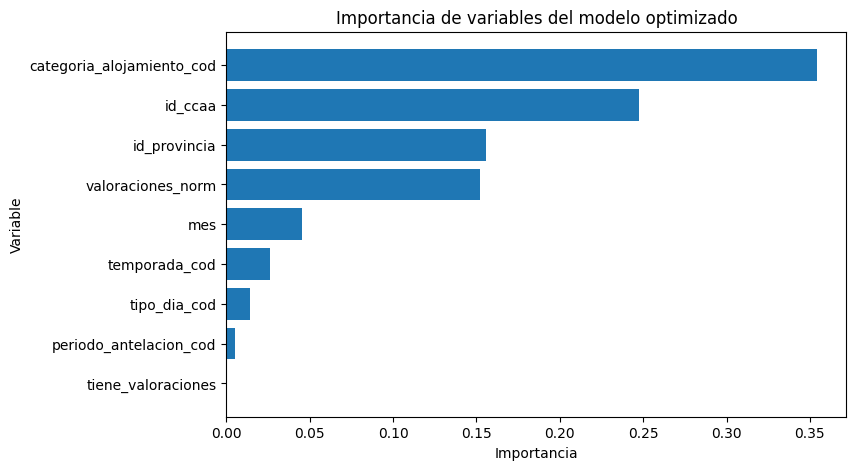

In [98]:
plt.figure(figsize=(8, 5))
plt.barh(importancias["variable"], importancias["importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables del modelo optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## Persistencia del modelo final

Una vez validado el modelo optimizado, se reentrenó sobre el conjunto completo de datos y se almacenó en formato `.pkl`, junto con la lista de variables predictoras necesarias para la inferencia posterior.

In [99]:
modelo_final = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(X, y)

model_path = MODEL_DIR / "random_forest_precio.pkl"
features_path = MODEL_DIR / "features_modelo_precio.pkl"

with open(model_path, "wb") as archivo_modelo:
    pickle.dump(modelo_final, archivo_modelo)

with open(features_path, "wb") as archivo_features:
    pickle.dump(features, archivo_features)

print(model_path)
print(features_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\random_forest_precio.pkl
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\features_modelo_precio.pkl


In [100]:
with open(model_path, "rb") as archivo_modelo:
    modelo = pickle.load(archivo_modelo)

with open(features_path, "rb") as archivo_features:
    features_guardadas = pickle.load(archivo_features)

## Carga del modelo persistido

Para verificar la consistencia del proceso, se recarga el modelo almacenado y la lista de variables necesarias para realizar predicciones posteriores.

In [101]:
def calcular_noches(fecha_inicio, fecha_fin):
    fecha_inicio = datetime.strptime(fecha_inicio, "%Y-%m-%d")
    fecha_fin = datetime.strptime(fecha_fin, "%Y-%m-%d")

    noches = []
    fecha_actual = fecha_inicio

    while fecha_actual < fecha_fin:
        noches.append(fecha_actual)
        fecha_actual += timedelta(days=1)

    return noches

def separar_noches(noches):
    noches_semana = 0
    noches_fin_semana = 0

    for fecha in noches:
        if fecha.weekday() >= 4:
            noches_fin_semana += 1
        else:
            noches_semana += 1

    return noches_semana, noches_fin_semana

def predecir_precio(features_guardadas):
    df_input = pd.DataFrame([features_guardadas])
    return modelo.predict(df_input)[0]

## Nota metodológica sobre presupuesto

En esta simulación, la suficiencia presupuestaria del alojamiento no se evalúa contra el presupuesto total del viaje, sino contra la fracción del presupuesto asignada a esta categoría.

En el modelo analítico de CulturaTrip, se considera que el **35% del presupuesto total** corresponde a alojamiento. Esta decisión permite una evaluación más realista y coherente con la distribución presupuestaria utilizada en el proyecto.

## Simulación de caso de uso

A continuación, se presenta una simulación de un caso de usuario para estimar el coste total del alojamiento. La lógica considera por separado las noches entre semana y de fin de semana, con el objetivo de reflejar mejor el comportamiento del precio en contextos turísticos.

In [102]:
usuario = {
    "presupuesto": 8000,
    "fecha_inicio": "2025-07-10",
    "fecha_fin": "2025-07-15",
    "id_ccaa": 1,
    "id_provincia": 29,
    "mes": 7,
    "temporada_cod": 3,
    "categoria_alojamiento_cod": 2,
    "periodo_antelacion_cod": 3,
    "valoraciones_norm": 4.2,
    "tiene_valoraciones": True
}

pct_alojamiento = 0.35
budget_alojamiento = usuario["presupuesto"] * pct_alojamiento

noches = calcular_noches(usuario["fecha_inicio"], usuario["fecha_fin"])
noches_semana, noches_fin_semana = separar_noches(noches)

input_semana = {
    "id_ccaa": usuario["id_ccaa"],
    "id_provincia": usuario["id_provincia"],
    "mes": usuario["mes"],
    "temporada_cod": usuario["temporada_cod"],
    "categoria_alojamiento_cod": usuario["categoria_alojamiento_cod"],
    "periodo_antelacion_cod": usuario["periodo_antelacion_cod"],
    "valoraciones_norm": usuario["valoraciones_norm"],
    "tiene_valoraciones": usuario["tiene_valoraciones"],
    "tipo_dia_cod": 0
}

input_fin_semana = input_semana.copy()
input_fin_semana["tipo_dia_cod"] = 1

precio_semana = predecir_precio(input_semana)
precio_fin_semana = predecir_precio(input_fin_semana)

coste_total = noches_semana * precio_semana + noches_fin_semana * precio_fin_semana

print("Presupuesto total:", round(usuario["presupuesto"], 2))
print("Presupuesto disponible para alojamiento:", round(budget_alojamiento, 2))
print("Noches semana:", noches_semana)
print("Noches fin de semana:", noches_fin_semana)
print("Precio estimado semana:", round(precio_semana, 2))
print("Precio estimado fin semana:", round(precio_fin_semana, 2))
print("Coste total estimado alojamiento:", round(coste_total, 2))

if budget_alojamiento >= coste_total:
    print("El presupuesto de alojamiento ALCANZA para este viaje.")
else:
    print("El presupuesto de alojamiento NO alcanza para este viaje.")

Presupuesto total: 8000
Presupuesto disponible para alojamiento: 2800.0
Noches semana: 2
Noches fin de semana: 3
Precio estimado semana: 86.94
Precio estimado fin semana: 104.29
Coste total estimado alojamiento: 486.76
El presupuesto de alojamiento ALCANZA para este viaje.


## Interpretación de la simulación

La simulación permite traducir el modelo predictivo a un caso de uso comprensible para el usuario final. En este escenario, el sistema estima el coste del alojamiento a partir de las características del viaje y compara el resultado con el presupuesto disponible asignado a esta categoría.

Este enfoque mejora la coherencia económica del prototipo, ya que evita comparar el coste del alojamiento contra el presupuesto total del viaje y lo evalúa únicamente contra la fracción destinada a hospedaje.

## Limitaciones del modelo

A pesar de su utilidad, el modelo presenta algunas limitaciones. En primer lugar, utiliza variables agregadas y codificadas, por lo que no incorpora todos los factores que pueden influir en el precio real del alojamiento, como promociones puntuales, eventos específicos o cambios abruptos de demanda.

En segundo lugar, algunas variables deben aproximarse mediante supuestos o valores promedio en escenarios donde no se dispone de información individual detallada del usuario.

Finalmente, al tratarse de un prototipo académico, el sistema no se encuentra conectado en tiempo real con proveedores externos de precios dinámicos, por lo que los resultados deben interpretarse como estimaciones analíticas y no como cotizaciones comerciales definitivas.

## Conclusión

El modelo de Machine Learning desarrollado permite estimar de forma razonable el precio del alojamiento turístico a partir de variables geográficas, temporales y contextuales. Su integración dentro del prototipo CulturaTrip aporta valor práctico, ya que transforma la predicción en una herramienta útil para la planificación financiera del viaje.

Desde una perspectiva metodológica, el desarrollo del modelo incluyó preparación del dataset, ingeniería de variables, comparación de algoritmos, optimización de hiperparámetros, validación, evaluación mediante métricas, análisis de importancia de variables y persistencia del modelo final.